# Problem 4 — Distance Concentration and the Curse of Dimensionality

We study the behaviour of the ratio
$$R := \frac{\max_{i \neq j} \|X_i - X_j\|}{\min_{i \neq j} \|X_i - X_j\|}$$
for $X_1, \dots, X_{10} \overset{\text{i.i.d.}}{\sim} N_d(0, I_d)$ as $d \to \infty$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

rng = np.random.default_rng(42)

## Part (a): Simulation

In [2]:
d_values = [2, 5, 10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
n_rep = 200  # independent repetitions per d to get a stable estimate
n_points = 10

R_means = []
R_stds  = []

for d in d_values:
    ratios = []
    for _ in range(n_rep):
        X = rng.standard_normal((n_points, d))   # 10 x d matrix, rows are X_1,...,X_10
        dists = pdist(X)                          # all C(10,2)=45 pairwise Euclidean distances
        R = dists.max() / dists.min()
        ratios.append(R)
    R_means.append(np.mean(ratios))
    R_stds.append(np.std(ratios))

R_means = np.array(R_means)
R_stds  = np.array(R_stds)

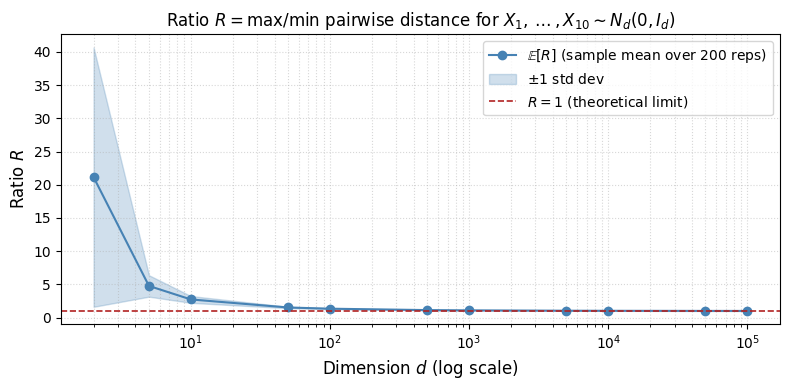

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(d_values, R_means, marker='o', color='steelblue', label=r'$\mathbb{E}[R]$ (sample mean over 200 reps)')
ax.fill_between(
    d_values,
    R_means - R_stds,
    R_means + R_stds,
    alpha=0.25,
    color='steelblue',
    label=r'$\pm 1$ std dev'
)
ax.axhline(1, color='firebrick', linestyle='--', linewidth=1.2, label='$R = 1$ (theoretical limit)')

ax.set_xscale('log')
ax.set_xlabel('Dimension $d$ (log scale)', fontsize=12)
ax.set_ylabel('Ratio $R$', fontsize=12)
ax.set_title(r'Ratio $R = \max / \min$ pairwise distance for $X_1,\dots,X_{10}\sim N_d(0,I_d)$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_q4_ratio.pdf', bbox_inches='tight')
plt.show()

**Observation.** The plot confirms that $R \to 1$ as $d \to \infty$: for small $d$ the ratio is substantially above 1 (distances can be very different from each other), but it approaches 1 rapidly as $d$ grows. The standard deviation also collapses, indicating tight concentration.

---

## Part (b): Theoretical Explanation

### Setup

Fix any pair $(i, j)$ with $i \neq j$.  The squared Euclidean distance is

$$\|X_i - X_j\|^2 = \sum_{k=1}^{d} (X_{i,k} - X_{j,k})^2.$$

### Distribution of each summand

Since $X_{i,k}, X_{j,k} \overset{\text{i.i.d.}}{\sim} N(0,1)$, their difference satisfies

$$Z_k := X_{i,k} - X_{j,k} \sim N(0, 2),$$

so the squared differences $Z_k^2$ are i.i.d. with

$$\mathbb{E}[Z_k^2] = \operatorname{Var}(Z_k) = 2, \qquad \operatorname{Var}(Z_k^2) = \mathbb{E}[Z_k^4] - 4 = 3 \cdot 4 - 4 = 8.$$

### Law of Large Numbers — convergence in probability

By the **Law of Large Numbers**, as $d \to \infty$,

$$\frac{1}{d}\|X_i - X_j\|^2 = \frac{1}{d}\sum_{k=1}^{d} Z_k^2 \xrightarrow{\;p\;} \mathbb{E}[Z_k^2] = 2.$$

Equivalently, $\|X_i - X_j\|^2 / (2d) \xrightarrow{p} 1$, so

$$\frac{\|X_i - X_j\|}{\sqrt{2d}} \xrightarrow{\;p\;} 1 \qquad \text{as } d\to\infty.$$

### Rate of concentration (CLT)

A sharper statement follows from the **Central Limit Theorem**:

$$\frac{\|X_i - X_j\|^2 - 2d}{\sqrt{8d}} \xrightarrow{d} N(0,1),$$

so the fluctuations of $\|X_i - X_j\|^2$ around its mean $2d$ are of order $\sqrt{d}$, giving a **coefficient of variation** of order $d^{-1/2} \to 0$.

### Consequence for $R$

There are only $\binom{10}{2} = 45$ pairs, a **fixed** finite number independent of $d$. Each of the 45 pairwise distances $\|X_i - X_j\|$ concentrates around $\sqrt{2d}$; since the maximum of 45 quantities all close to $\sqrt{2d}$ divided by the minimum of 45 quantities all close to $\sqrt{2d}$ also converges to 1, we obtain

$$R = \frac{\max_{i\neq j}\|X_i-X_j\|}{\min_{i\neq j}\|X_i-X_j\|} \xrightarrow{\;p\;} 1 \qquad \text{as } d \to \infty.$$

Formally, for any $\varepsilon > 0$,

$$P\!\left(\left|\frac{\|X_i - X_j\|}{\sqrt{2d}} - 1\right| > \varepsilon\right) \to 0,$$

and a union bound over the 45 pairs gives the same for both the maximum and the minimum simultaneously, so the ratio converges in probability to 1.

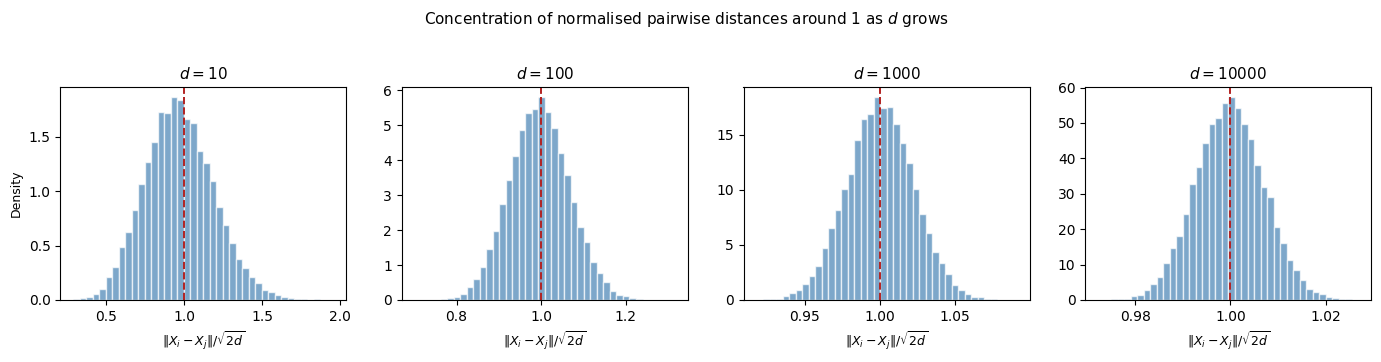

In [4]:
# Verify: check that the normalised distances ||X_i - X_j|| / sqrt(2d) -> 1
d_check = [10, 100, 1_000, 10_000]
n_rep_check = 500

fig, axes = plt.subplots(1, len(d_check), figsize=(14, 3.5), sharey=False)

for ax, d in zip(axes, d_check):
    all_norm = []
    for _ in range(n_rep_check):
        X = rng.standard_normal((n_points, d))
        dists = pdist(X) / np.sqrt(2 * d)   # normalised distances
        all_norm.extend(dists.tolist())
    ax.hist(all_norm, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(1, color='firebrick', linestyle='--', linewidth=1.4)
    ax.set_title(f'$d = {d}$', fontsize=11)
    ax.set_xlabel(r'$\|X_i - X_j\| / \sqrt{2d}$', fontsize=9)
    ax.set_ylabel('Density' if d == d_check[0] else '', fontsize=9)

fig.suptitle(r'Concentration of normalised pairwise distances around 1 as $d$ grows', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_q4_concentration.pdf', bbox_inches='tight')
plt.show()

The histograms above confirm the theoretical prediction: as $d$ increases, the distribution of $\|X_i - X_j\|/\sqrt{2d}$ becomes increasingly concentrated at 1, with variance shrinking at the rate $O(1/d)$ predicted by the CLT.

---

## Part (c): Relation to the Curse of Dimensionality

The convergence $R \to 1$ is a precise manifestation of the **curse of dimensionality** in the following sense.

**Loss of metric relevance.**  
When $R \approx 1$, every pair of points is roughly equidistant.  Euclidean distance can no longer meaningfully distinguish between a "near" neighbour and a "far" neighbour: the concept of nearest-neighbour essentially breaks down.

**Impact on distance-based algorithms.**  
Many unsupervised learning methods rely on pairwise distances to partition or embed data:

- **$K$-means / $K$-medoids** (Week 3): cluster assignment is driven by which centroid is *closest*. If all distances are equal, every point is equidistant from every centroid and cluster assignments become arbitrary.
- **MDS** (Week 4): multidimensional scaling attempts to embed points so that pairwise distances are preserved. If all distances concentrate at the same value $\sqrt{2d}$, the data look like points on a sphere and a low-dimensional embedding that preserves structure ceases to exist.

**Rationale for dimensionality reduction.**  
The behaviour of $R$ is the key motivation for reducing the dimensionality of data *before* applying distance-based methods. Techniques such as PCA (Week 2/3) and ICA (Week 2) seek a lower-dimensional representation in which distances remain informative and the ratio $R$ is bounded away from 1.